In [66]:
# !pip install openai pillow requests

In [67]:
import os
from dotenv import load_dotenv
from openai import OpenAI
import base64, requests
from io import BytesIO
from PIL import Image

load_dotenv(".env")  # o solo load_dotenv() si está en el mismo directorio

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")

if not OPENROUTER_API_KEY:
    raise ValueError("No se encontró OPENROUTER_API_KEY en el .env")

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=OPENROUTER_API_KEY,
)

MODEL = "google/gemini-2.0-flash-lite-001"
print("Cliente OpenRouter configurado")

Cliente OpenRouter configurado


In [68]:
response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {"role": "user", "content": "Di 'conexión OK' y el modelo que eres."}
    ]
)

print(response.choices[0].message.content)

Conexión OK. Soy un modelo de lenguaje grande, entrenado por Google.



In [69]:
def image_to_base64(source, format="JPEG"):
    """
    Convierte imagen a base64.
    source: ruta local (str) | URL (str) | PIL.Image
    """
    if isinstance(source, str) and source.startswith("http"):
        img_data = requests.get(source).content
        img = Image.open(BytesIO(img_data))
    elif isinstance(source, str):
        img = Image.open(source)
    else:
        img = source  # PIL Image directamente

    # Convertir a RGB si hace falta (evita errores con PNG RGBA)
    if img.mode in ("RGBA", "P"):
        img = img.convert("RGB")

    buffer = BytesIO()
    img.save(buffer, format=format)
    b64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
    mime = f"image/{format.lower()}"
    return b64, mime

Imagen seleccionada: c:\Users\FadouaHt\Documents\DocumentosCurso\ProyectoFinal_CSEBDIA\CNN_desde_0\imagenes_procesadas\test\si\img_1776863909985.png
Clase: si


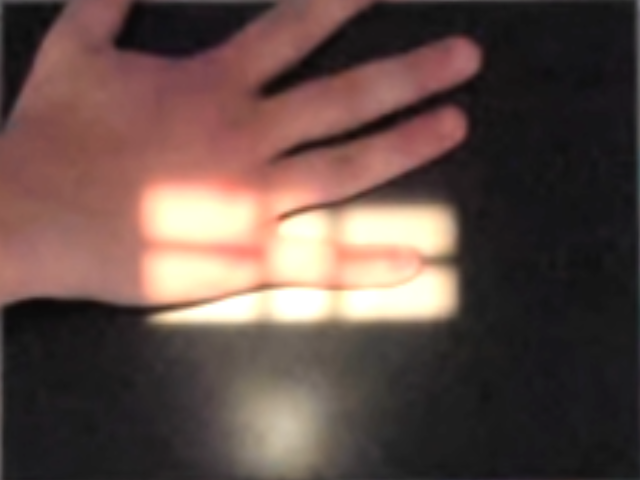

In [70]:
import os
import random
from pathlib import Path
from IPython.display import display, Image as IPImage

# --- Localizar imagenes_procesadas buscando hacia arriba ---
def find_imagenes_procesadas():
    start = Path.cwd()
    for path in [start, start.parent, start.parent.parent, start.parent.parent.parent]:
        candidate = path / "CNN_desde_0" / "imagenes_procesadas"
        if candidate.exists():
            return candidate
        candidate = path / "imagenes_procesadas"
        if candidate.exists():
            return candidate
    return None

BASE_DIR = find_imagenes_procesadas()
if BASE_DIR is None:
    raise FileNotFoundError("No se encontró la carpeta 'imagenes_procesadas'.")
# -----------------------------------------------------------

def get_random_image():
    todas = (
        list(BASE_DIR.rglob("*.jpg")) +
        list(BASE_DIR.rglob("*.jpeg")) +
        list(BASE_DIR.rglob("*.png"))
    )
    if not todas:
        raise FileNotFoundError(f"No se encontraron imágenes en {BASE_DIR}")
    
    elegida = random.choice(todas)
    clase = elegida.parts[-2]  # 'si' o 'no'
    
    print(f"Imagen seleccionada: {elegida}")
    print(f"Clase: {clase}")
    
    # Mostrar la imagen en el notebook
    display(IPImage(filename=str(elegida)))
    
    return elegida

img_path = get_random_image()

## PRUEBA DE QUE FUNCIONA EL MODELO   

In [71]:
# b64, mime = image_to_base64(str(img_path))

# response = client.chat.completions.create(
#     model=MODEL,
#     messages=[
#         {
#             "role": "user",
#             "content": [
#                 {
#                     "type": "image_url",
#                     "image_url": {"url": f"data:{mime};base64,{b64}"}
#                 },
#                 {
#                     "type": "text",
#                     "text": "Describe detalladamente lo que ves en esta imagen."
#                 }
#             ]
#         }
#     ]
# )

# print(f"\nRespuesta del modelo:")
# print(response.choices[0].message.content)

# Diseñar los prompts para clasificación zero-shot: 

In [72]:
# --- Prompts Zero-Shot para clasificación ---
DESCRIPCION_CLASES = {
    "si": (
        "Postura CORRECTA. "
        "Hay luz activa. "
        "Un único dedo extendido está colocado directamente sobre la barra de luz anaranjada/roja del panel. "
        "La luz ilumina frontalmente el dedo. "
        "El dedo está centrado y alineado con la zona luminosa del escáner. "
        "No hay otros dedos ni partes de la mano interfiriendo en la zona activa. "
        "El dedo está dentro de la caja negra."
    ),
    "no": (
        "Postura INCORRECTA. "
        "No hay luz activa. "
        "La mano no está colocada correctamente sobre la zona de luz. "
        "Puede tratarse de: varios dedos sobre el panel, mano abierta, dedos doblados, sobre la luz. "
        "Dedo desplazado fuera de la barra luminosa, o cualquier posición que no permita "
        "el escaneo frontal del dedo sobre la luz anaranjada. "
        "El dedo no está dentro de la caja negra o hay interferencias en la zona activa."
    )
}

zero_shot_prompt = (
    "Actúa como un validador de posicionamiento de escaneo de dedo. "
    "Analiza la imagen y clasifícala según una de estas dos categorías:\n\n"
    f"CATEGORÍA 'SI' - {DESCRIPCION_CLASES['si']}\n\n"
    f"CATEGORÍA 'NO' - {DESCRIPCION_CLASES['no']}\n\n"
    "Responde ÚNICAMENTE en formato JSON con esta estructura exacta:\n"
    '{\n'
    '  "veredicto": "SI" o "NO",\n'
    '  "confianza": número entre 0.0 y 1.0,\n'
    '  "justificacion": "una frase corta explicando qué se ve en la imagen y por qué es SI o NO"\n'
    '}'
)

response = client.chat.completions.create(
    model=MODEL,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "image_url",
                    "image_url": {"url": f"data:{mime};base64,{b64}"}
                },
                {
                    "type": "text",
                    "text": zero_shot_prompt
                }
            ]
        }
    ],
    temperature=0.1,
    max_tokens=256
)

print(f"\nRespuesta del modelo:")
print(response.choices[0].message.content)


Respuesta del modelo:
```json
{
  "veredicto": "SI",
  "confianza": 0.9,
  "justificacion": "Un dedo extendido está colocado sobre la barra de luz, centrado y alineado, permitiendo el escaneo frontal."
}
```


# Ejecutar la clasificación sobre el mismo subconjunto de 50-100 imágenes

En proceso de Solución:  AUN ME DA ERROR

In [74]:
# ---------- SOLO NUEVO: Prompts Zero-Shot ----------
from streamlit import json


DESCRIPCION_CLASES = {
    "si": (
        "Postura CORRECTA. Hay luz activa. "
        "Un único dedo extendido está colocado directamente sobre la barra de luz anaranjada/roja del panel. "
        "La luz ilumina frontalmente el dedo. El dedo está centrado y alineado con la zona luminosa. "
        "No hay otros dedos ni partes de la mano interfiriendo. El dedo está dentro de la caja negra."
    ),
    "no": (
        "Postura INCORRECTA. No hay luz activa. "
        "La mano no está colocada correctamente sobre la zona de luz. "
        "Puede ser: varios dedos sobre el panel, mano abierta, dedos doblados, sobre la luz, "
        "dedo desplazado fuera de la barra luminosa, o cualquier posición que no permita "
        "el escaneo frontal del dedo sobre la luz anaranjada. "
        "El dedo no está dentro de la caja negra o hay interferencias."
    )
}

ZERO_SHOT_PROMPT = (
    "Actúa como validador de posicionamiento de escaneo de dedo. "
    "Clasifica la imagen en SI o NO según estas categorías:\n\n"
    f"SI = {DESCRIPCION_CLASES['si']}\n\n"
    f"NO = {DESCRIPCION_CLASES['no']}\n\n"
    'Responde ÚNICAMENTE en JSON: {"veredicto":"SI"|"NO","confianza":0.0-1.0,"justificacion":"..."}'
)

# ---------- SOLO NUEVO: Clasificación unitaria ----------
def clasificar(img_path: Path, real: str) -> dict:
    b64, mime = image_to_base64(str(img_path))
    try:
        r = client.chat.completions.create(
            model=MODEL,
            messages=[{
                "role": "user",
                "content": [
                    {"type": "image_url", "image_url": {"url": f"data:{mime};base64,{b64}"}},
                    {"type": "text", "text": ZERO_SHOT_PROMPT}
                ]
            }],
            temperature=0.1,
            max_tokens=256
        )
        raw = r.choices[0].message.content or ""
    except Exception as e:
        return {"archivo": str(img_path), "real": real, "pred": "ERROR", "conf": 0.0, "raw": str(e)}

    # Parseo
    pred, conf, just = "ERROR", 0.0, "parseo fallido"
    try:
        txt = raw.strip()
        if txt.startswith("```"): txt = txt.split("```")[1].split("```")[0].strip()
        d = json.loads(txt)
        pred = str(d.get("veredicto", "ERROR")).upper()
        conf = float(d.get("confianza", 0.0))
        just = d.get("justificacion", "")
    except Exception:
        pass
    return {"archivo": str(img_path), "real": real, "pred": pred, "conf": conf, "just": just, "raw": raw}

# ---------- SOLO NUEVO: Seleccionar muestras ----------
N = 50  # 50 por clase = 100 total. Ajusta si quieres.
muestras = []
for clase in ["si", "no"]:
    carpeta = BASE_DIR / clase
    imgs = list(carpeta.rglob("*.jpg")) + list(carpeta.rglob("*.jpeg")) + list(carpeta.rglob("*.png"))
    muestras += [(p, clase) for p in random.sample(imgs, min(N, len(imgs)))]
random.shuffle(muestras)
print(f"Muestras a clasificar: {len(muestras)}")

# ---------- SOLO NUEVO: Ejecutar batch ----------
resultados = []
for i, (p, real) in enumerate(muestras, 1):
    print(f"[{i}/{len(muestras)}] {p.name} (real={real})")
    res = clasificar(p, real)
    resultados.append(res)
    print(f"  → pred={res['pred']} conf={res['conf']:.2f}")

# ---------- SOLO NUEVO: Métricas ----------
validos = [r for r in resultados if r['pred'] in ("SI","NO")]
errores = [r for r in resultados if r['pred']=="ERROR"]
print(f"\nVálidos: {len(validos)} | Errores: {len(errores)}")

if validos:
    acc = sum(1 for r in validos if r['pred']==r['real'].upper()) / len(validos)
    print(f"Accuracy: {acc:.2%}")

    tp = sum(1 for r in validos if r['real']=="si" and r['pred']=="SI")
    fn = sum(1 for r in validos if r['real']=="si" and r['pred']=="NO")
    tn = sum(1 for r in validos if r['real']=="no" and r['pred']=="NO")
    fp = sum(1 for r in validos if r['real']=="no" and r['pred']=="SI")
    print(f"TP={tp} FN={fn} | TN={tn} FP={fp}")

# Guardar resultados
with open("resultados_zero_shot.jsonl","w",encoding="utf-8") as f:
    for r in resultados: f.write(json.dumps(r,ensure_ascii=False)+"\n")
print("Guardado: resultados_zero_shot.jsonl")

Muestras a clasificar: 0

Válidos: 0 | Errores: 0
Guardado: resultados_zero_shot.jsonl
